# Main Imports

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from matplotlib.ticker import MultipleLocator
import re
import os

# import data
cb_10x = os.path.join("..", "clean-files-ul", "aggr", "agg-cb-10.csv")
#cf_10x = os.path.join("..", "clean-files-ul", "aggr", "agg-cf-10.csv")
cb_5x = os.path.join("..", "clean-files-ul", "aggr", "agg-cb-5.csv")
#cf_5x = os.path.join("..", "clean-files-ul", "aggr", "agg-cf-5.csv")
cb_1x = os.path.join("..", "clean-files-ul", "aggr", "agg-cb-1.csv")
#cf_1x = os.path.join("..", "clean-files-ul", "aggr", "agg-cf-1-1.csv")

cb_10x_lt = os.path.join("..", "clean-files-latency", "aggr", "agg-cb-10.csv")
#cf_10x_lt = os.path.join("..", "clean-files-latency", "aggr", "agg-cf-10.csv")
cb_5x_lt = os.path.join("..", "clean-files-latency", "aggr", "agg-cb-5.csv")
#cf_5x_lt = os.path.join("..", "clean-files-latency", "aggr", "agg-cf-5.csv")
cb_1x_lt = os.path.join("..", "clean-files-latency", "aggr", "agg-cb-1.csv")
#cf_1x_lt = os.path.join("..", "clean-files-latency", "aggr", "agg-cf-1-1.csv")

# Calculations for every file

#### 1x Scenarios

In [79]:
# Read content of the file
df_cb_1 = pd.read_csv(cb_1x)
#df_cf_1 = pd.read_csv(cf_1x)

df_cb_1_lt = pd.read_csv(cb_1x_lt)
#df_cf_1_lt = pd.read_csv(cb_1x_lt)

df_cb_1_lt["Mean_Latency_ms"] = df_cb_1_lt["Mean_Latency_us"] / 1e6
df_cb_1_lt["Std_Latency_ms"]  = df_cb_1_lt["Std_Latency_us"] / 1e6

#df_cf_1_lt["Mean_Latency_ms"] = df_cf_1_lt["Mean_Latency_us"] / 1e6
#df_cf_1_lt["Std_Latency_ms"]  = df_cf_1_lt["Std_Latency_us"] / 1e6

#### 5x Scenarios

In [80]:
def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (Mbps)"] = df_ue["Mean_Throughput"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

dfs_cb_5 = read_data_by_ue(cb_5x)
#dfs_cf_5 = read_data_by_ue(cf_5x)

def read_latency_data(csv_path):
    df = pd.read_csv(csv_path)
    df = df.sort_values("Time_ms").reset_index(drop=True)
    df["Rolling Avg (us)"] = df["Mean_Latency_us"].rolling(window=5, min_periods=1).mean()

    return df

dfs_cb_5_lt = read_latency_data(cb_5x_lt)
#dfs_cf_5_lt = read_latency_data(cf_5x_lt)

dfs_cb_5_lt["Mean_Latency_ms"] = dfs_cb_5_lt["Mean_Latency_us"] / 1e6
dfs_cb_5_lt["Std_Latency_ms"]  = dfs_cb_5_lt["Std_Latency_us"] / 1e6

#dfs_cf_5_lt["Mean_Latency_ms"] = dfs_cf_5_lt["Mean_Latency_us"] / 1e6
#dfs_cf_5_lt["Std_Latency_ms"]  = dfs_cf_5_lt["Std_Latency_us"] / 1e6

#### 10x Scenarios

In [81]:
def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (Mbps)"] = df_ue["Mean_Throughput"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

def read_latency_data(csv_path):
    df = pd.read_csv(csv_path)
    df = df.sort_values("Time_ms").reset_index(drop=True)
    df["Rolling Avg (us)"] = df["Mean_Latency_us"].rolling(window=5, min_periods=1).mean()

    return df


dfs_cb_10_lt = read_latency_data(cb_10x_lt)
#dfs_cf_10_lt = read_latency_data(cf_10x_lt)

dfs_cb_10_lt["Mean_Latency_ms"] = dfs_cb_10_lt["Mean_Latency_us"] / 1e6
dfs_cb_10_lt["Std_Latency_ms"]  = dfs_cb_10_lt["Std_Latency_us"] / 1e6

#dfs_cf_10_lt["Mean_Latency_ms"] = dfs_cf_10_lt["Mean_Latency_us"] / 1e6
#dfs_cf_10_lt["Std_Latency_ms"]  = dfs_cf_10_lt["Std_Latency_us"] / 1e6


# Behavior Graphics 

## 1X Scenarios

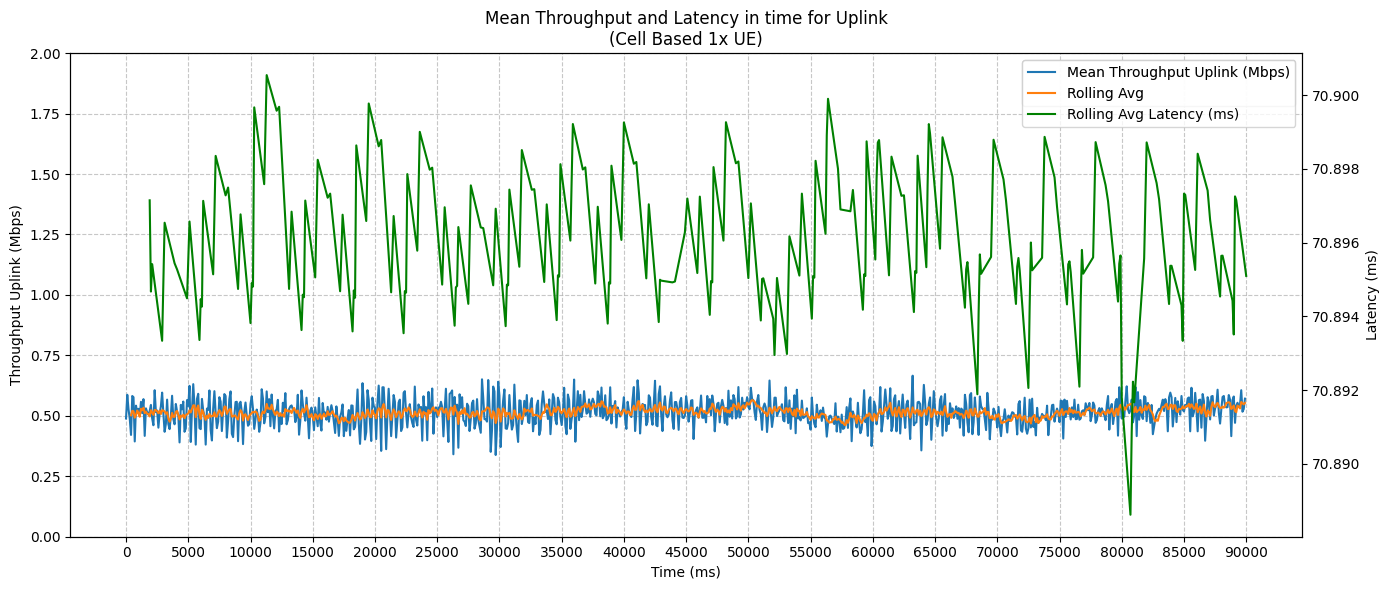

C:\Users\Ana Gouveia\AppData\Local\Temp\ipykernel_4132\4059151601.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


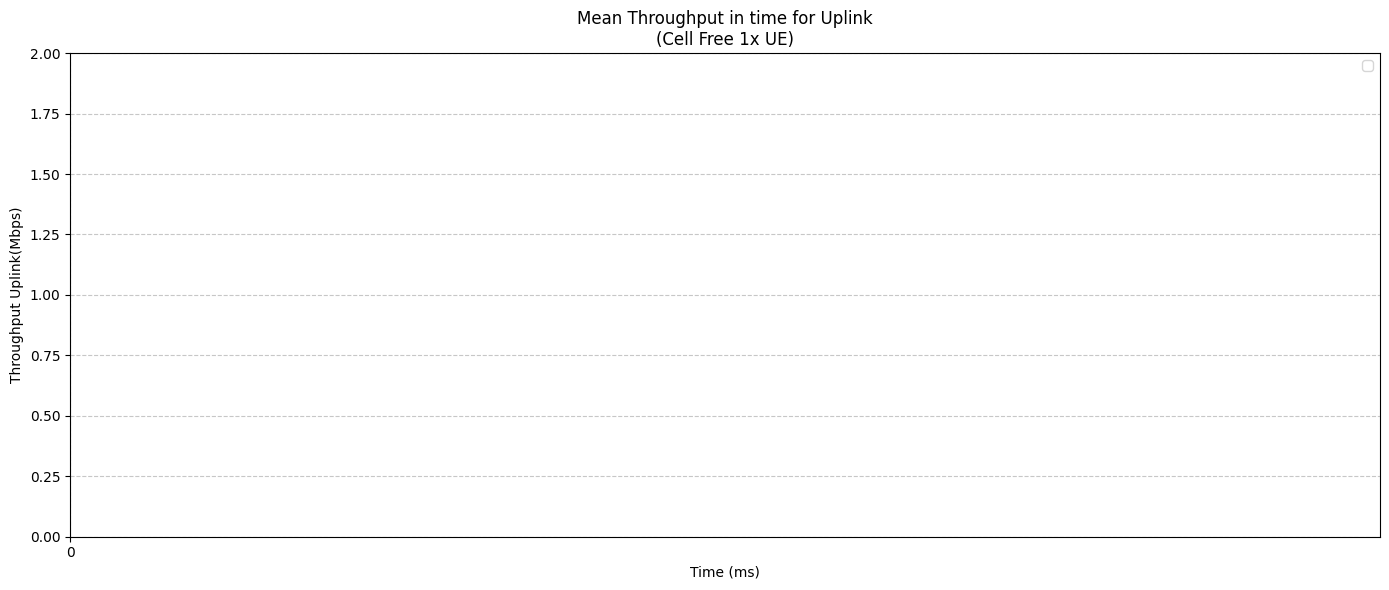

In [74]:
df_cb_1["Mean_Throughput"] = df_cb_1["Mean_Throughput"].round(3)
df_cb_1["Rolling Avg (Mbps)"] = df_cb_1["Mean_Throughput"].rolling(window=5).mean()
df_cb_1_lt["Rolling Avg Latency (ms)"] = df_cb_1_lt["Mean_Latency_ms"].rolling(window=5).mean()

# Graphic of Throughput and Rolling Average
fig, ax1 = plt.subplots(figsize=(14, 6))

sns.lineplot(x="Time_ms", y="Mean_Throughput", data=df_cb_1, label="Mean Throughput Uplink (Mbps)", ax=ax1)
sns.lineplot(x="Time_ms", y="Rolling Avg (Mbps)", data=df_cb_1, label="Rolling Avg", ax=ax1)

ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Throughput Uplink (Mbps)")
ax1.set_ylim(0, 2)
ax1.xaxis.set_major_locator(MultipleLocator(5000))
ax1.grid(True, linestyle="--", alpha=0.7)

ax2 = ax1.twinx()
sns.lineplot(x="Time_ms", y="Rolling Avg Latency (ms)", data=df_cb_1_lt, label="Rolling Avg Latency (ms)", color="green", ax=ax2)
ax2.set_ylabel("Latency (ms)")

plt.title("Mean Throughput and Latency in time for Uplink\n(Cell Based 1x UE)")
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper right")
plt.tight_layout()
plt.show()

#df_cf_1["Mean_Throughput"] = df_cf_1["Mean_Throughput"].round(3)
#df_cf_1["Rolling Avg (Mbps)"] = df_cf_1["Mean_Throughput"].rolling(window=5).mean()

# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
#sns.lineplot(x="Time_ms", y="Mean_Throughput", data=df_cf_1, label="Mean Throughput Uplink (mbps)")
#sns.lineplot(x="Time_ms", y="Rolling Avg (Mbps)", data=df_cf_1, label="Rolling Avg")
plt.title("Mean Throughput in time for Uplink\n(Cell Free 1x UE)")
plt.xlabel("Time (ms)")
plt.ylabel("Throughput Uplink(Mbps)")
plt.legend()

plt.ylim(0, 2)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [83]:
print(df_cb_1["Mean_Throughput"].describe())
#print(df_cf_1["Mean_Throughput"].describe())

count    900.000000
mean       0.514195
std        0.057486
min        0.338253
25%        0.475816
50%        0.515126
75%        0.557160
max        0.666345
Name: Mean_Throughput, dtype: float64


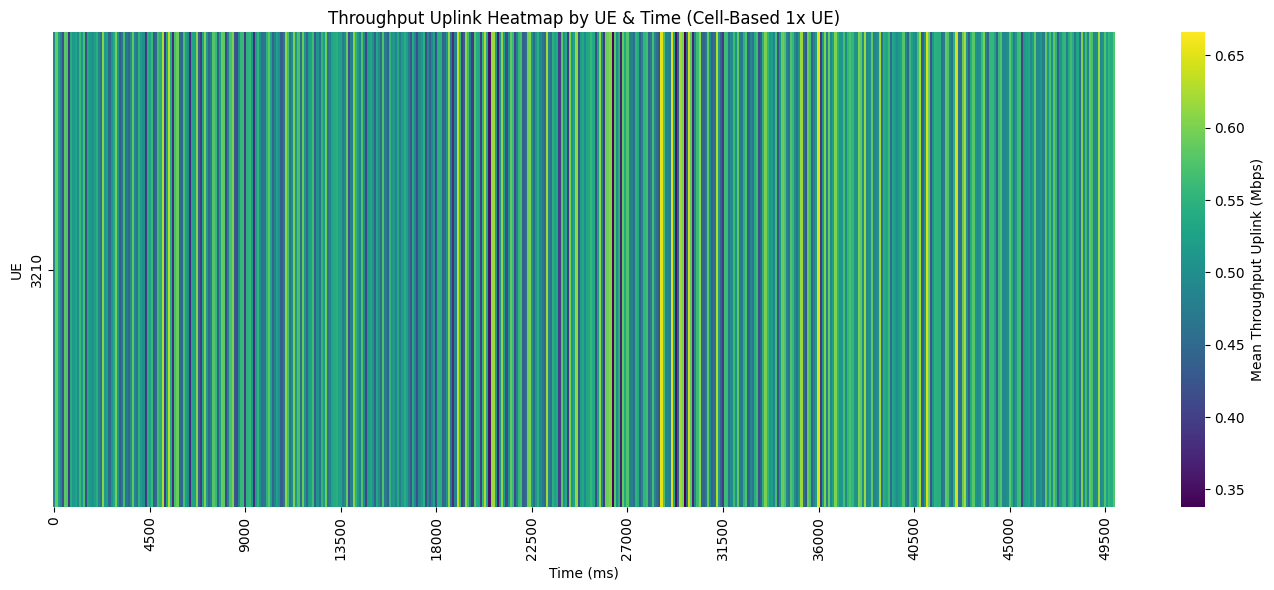

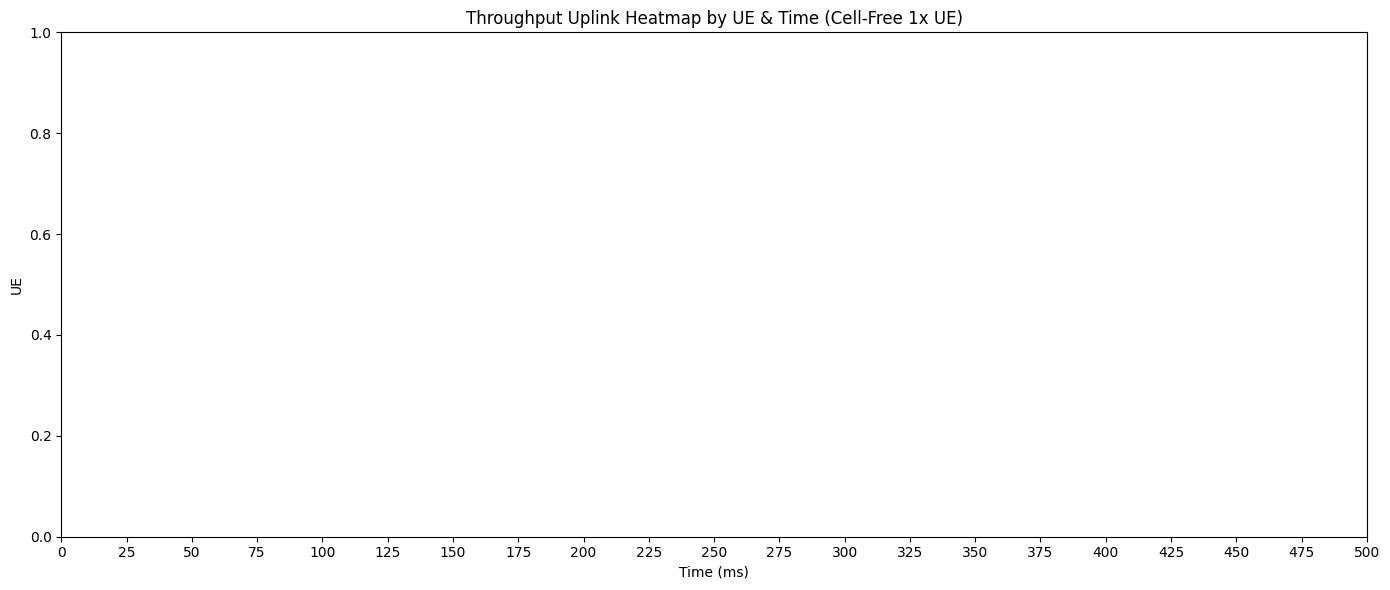

In [ ]:
heat_cb = df_cb_1.pivot(index="UE_ID", columns="Time_ms", values="Mean_Throughput")
#heat_cf = df_cf_1.pivot(index="UE_ID", columns="Time_ms", values="Mean_Throughput")

# Plot Cell-Based
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cb, cmap="viridis", cbar_kws={'label': 'Mean Throughput Uplink (Mbps)'})
plt.title("Throughput Uplink Heatmap by UE & Time (Cell-Based 1x UE)")
plt.xlabel("Time (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.tight_layout()
plt.xlim(0,500)
plt.show()

# Plot Cell-Free
plt.figure(figsize=(14, 6))
#sns.heatmap(heat_cf, cmap="viridis", cbar_kws={'label': 'Mean Throughput Uplink (Mbps)'})
plt.title("Throughput Uplink Heatmap by UE & Time (Cell-Free 1x UE)")
plt.xlabel("Time (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.xlim(0,500)
plt.tight_layout()
plt.show()

## 5X Scenarios

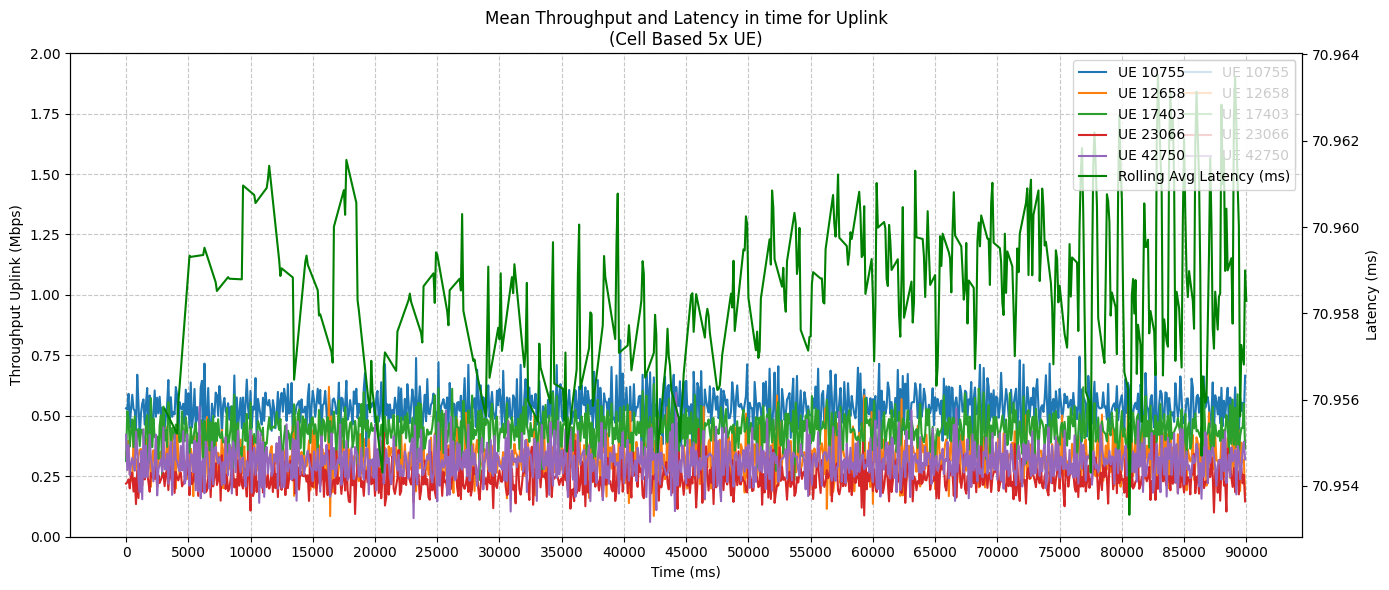

C:\Users\Ana Gouveia\AppData\Local\Temp\ipykernel_4132\4045302832.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


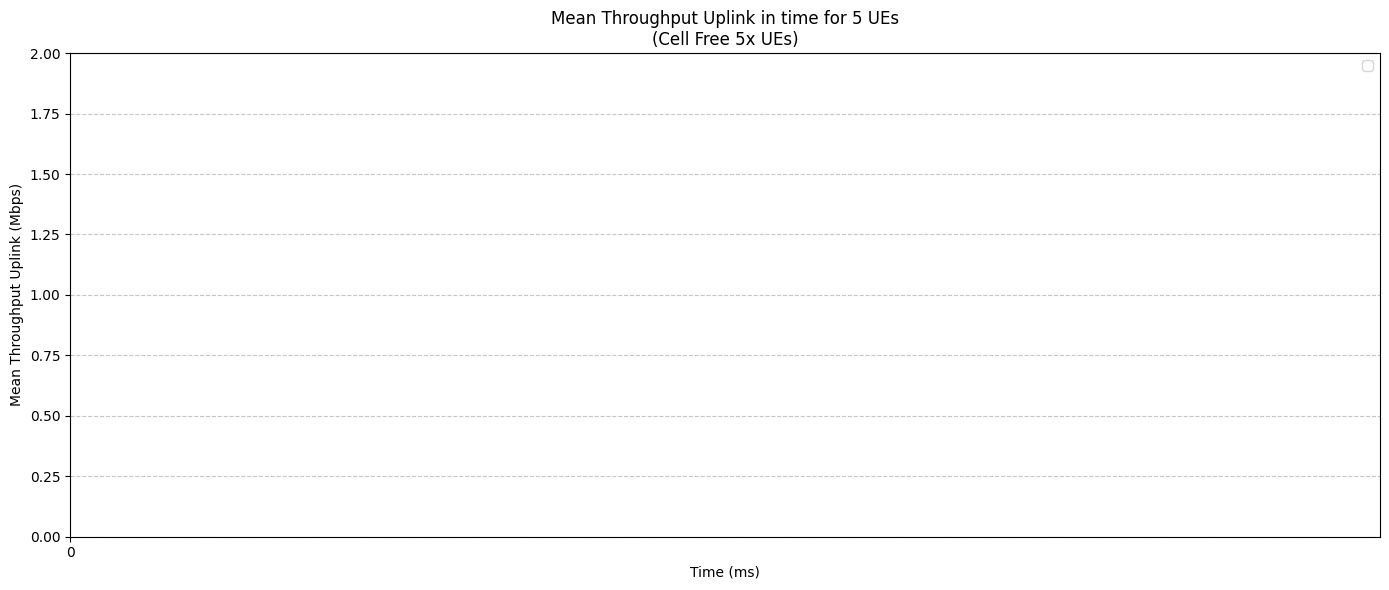

In [90]:
# Graphic of Throughput and Rolling Average
fig, ax1 = plt.subplots(figsize=(14, 6))

for ue, df in dfs_cb_5.items():
    dfs_cb_5[ue]["Mean_Throughput"] = dfs_cb_5[ue]["Mean_Throughput"].round(3)

    sns.lineplot(x="Time_ms", y="Mean_Throughput", data=df, label=f"UE {ue}")


ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Throughput Uplink (Mbps)")
ax1.set_ylim(0, 2)
ax1.xaxis.set_major_locator(MultipleLocator(5000))
ax1.grid(True, linestyle="--", alpha=0.7)

ax2 = ax1.twinx()
dfs_cb_5_lt["Rolling Avg Latency (ms)"] = dfs_cb_5_lt["Mean_Latency_ms"].rolling(window=5).mean()
sns.lineplot(x="Time_ms", y="Rolling Avg Latency (ms)", data=dfs_cb_5_lt, label="Rolling Avg Latency (ms)", color="green", ax=ax2)
ax2.set_ylabel("Latency (ms)")

plt.title("Mean Throughput and Latency in time for Uplink\n(Cell Based 5x UE)")
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper right")
plt.tight_layout()
plt.show()



plt.figure(figsize=(14, 6))

# Graphic of Throughput and Rolling Average
#for ue, df in dfs_cf_5.items():
#    dfs_cf_5[ue]["Mean_Throughput"] = dfs_cf_5[ue]["Mean_Throughput"].round(3)

#    sns.lineplot(x="Time_ms", y="Mean_Throughput", data=df, label=f"UE {ue}")

plt.title("Mean Throughput Uplink in time for 5 UEs\n(Cell Free 5x UEs)")
plt.xlabel("Time (ms)")
plt.ylabel("Mean Throughput Uplink (Mbps)")
plt.grid(True)
plt.legend()

plt.ylim(0, 2)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [96]:
df_cb_5 = pd.read_csv(cb_5x)
#df_cf_5 = pd.read_csv(cf_5x)

print(df_cb_5["Mean_Throughput"].describe())
#print(df_cf_5["Mean_Throughput"].describe())


df_cb_5_lt = pd.read_csv(cb_5x_lt)
#df_cf_5_lt = pd.read_csv(cf_5x_lt)

print(df_cb_5_lt["Mean_Latency_us"].describe())
#print(df_cf_5_lt["Mean_Throughput"].describe())

count    4500.000000
mean        0.370776
std         0.126666
min         0.060673
25%         0.268528
50%         0.354878
75%         0.465766
max         0.813157
Name: Mean_Throughput, dtype: float64
count    4.280000e+02
mean     7.095865e+07
std      5.454288e+03
min      7.094294e+07
25%      7.095533e+07
50%      7.095924e+07
75%      7.096154e+07
max      7.097518e+07
Name: Mean_Latency_us, dtype: float64


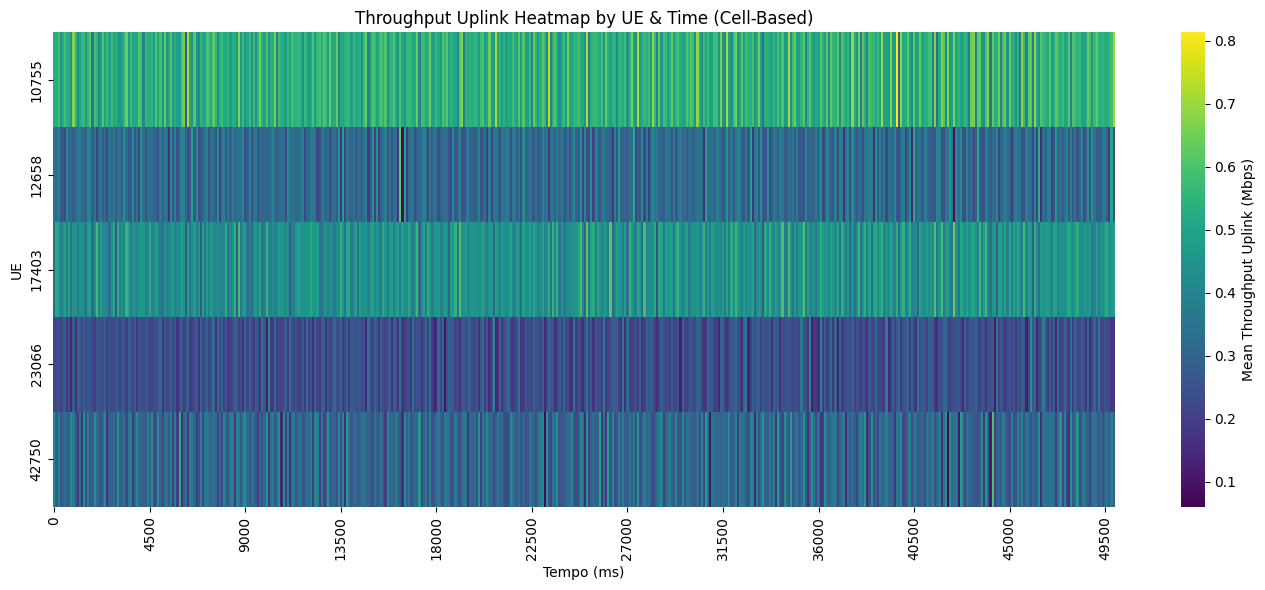

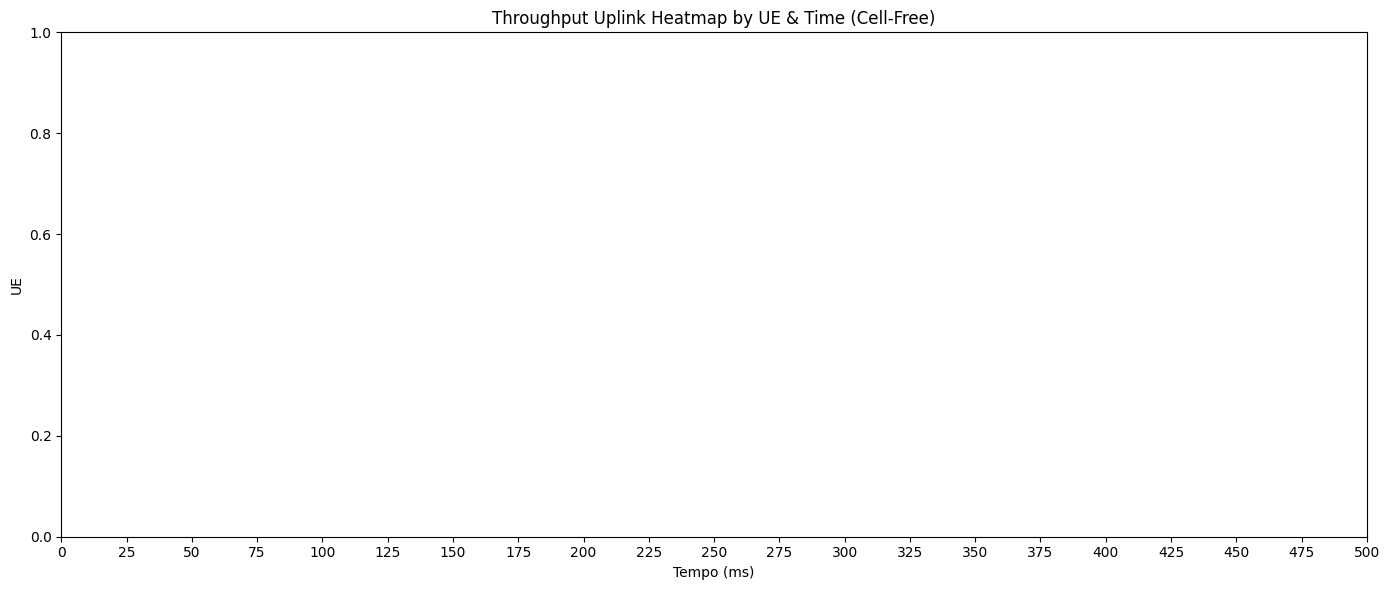

In [92]:
heat_cb = df_cb_5.pivot(index="UE_ID", columns="Time_ms", values="Mean_Throughput")
#heat_cf = df_cf_5.pivot(index="UE_ID", columns="Time_ms", values="Mean_Throughput")

# Plot Cell-Based
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cb, cmap="viridis", cbar_kws={'label': 'Mean Throughput Uplink (Mbps)'})
plt.title("Throughput Uplink Heatmap by UE & Time (Cell-Based)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.tight_layout()
plt.xlim(0,500)
plt.show()

# Plot Cell-Free
plt.figure(figsize=(14, 6))
#sns.heatmap(heat_cf, cmap="viridis", cbar_kws={'label': 'Mean Throughput Uplink (Mbps)'})
plt.title("Throughput Uplink Heatmap by UE & Time (Cell-Free)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.xlim(0,500)
plt.tight_layout()
plt.show()

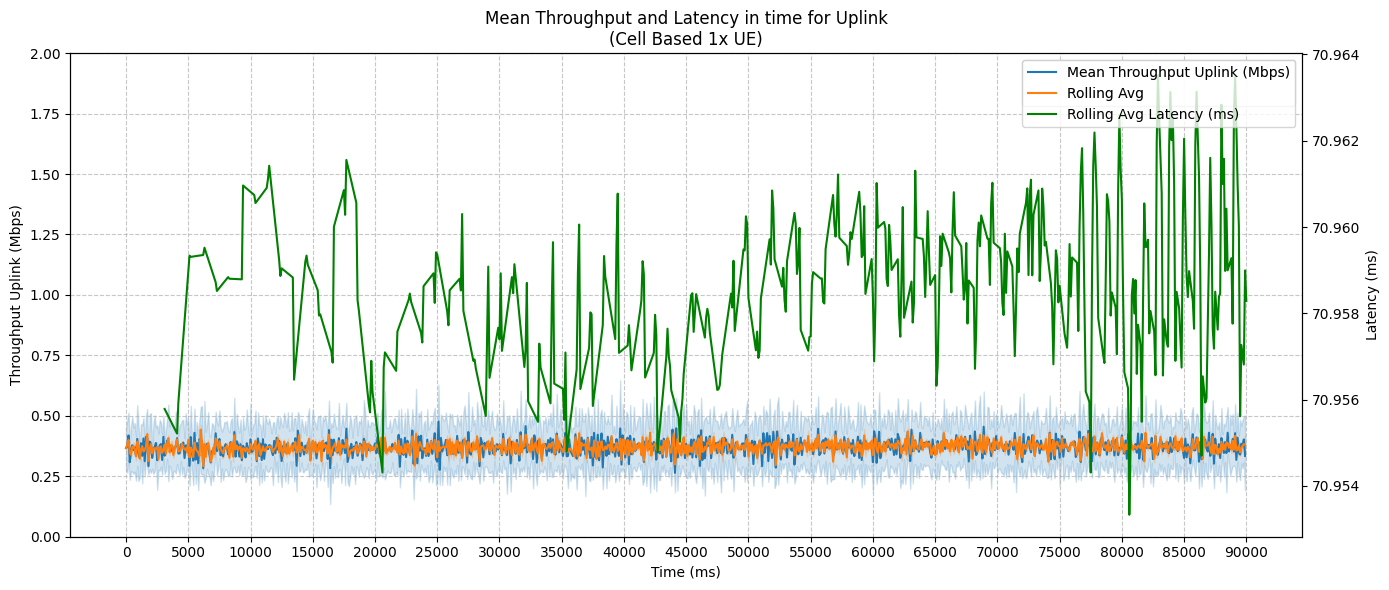

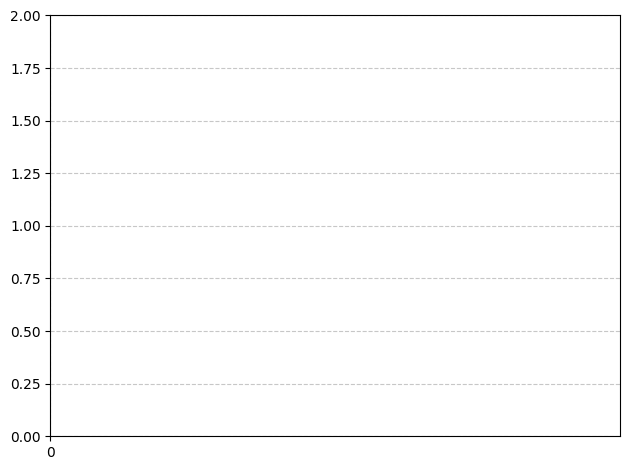

In [97]:
df_cb_5["Mean_Throughput"] = df_cb_5["Mean_Throughput"].round(3)
df_cb_5["Rolling Avg (Mbps)"] = df_cb_5["Mean_Throughput"].rolling(window=5).mean()

df_cb_5_lt["Mean_Latency_ms"] = df_cb_5_lt["Mean_Latency_us"] / 1e6
df_cb_5_lt["Rolling Avg Latency (ms)"] = df_cb_5_lt["Mean_Latency_ms"].rolling(window=5).mean()

# Round of throughput values to 3 decimal places
#df_cf_5["Mean_Throughput"] = df_cf_5["Mean_Throughput"].round(3)
# Calculate rolling average with a window of 5
#df_cf_5["Rolling Avg (Mbps)"] = df_cf_5["Mean_Throughput"].rolling(window=5).mean()

# Graphic of Throughput and Rolling Average
fig, ax1 = plt.subplots(figsize=(14, 6))

sns.lineplot(x="Time_ms", y="Mean_Throughput", data=df_cb_5, label="Mean Throughput Uplink (Mbps)", ax=ax1)
sns.lineplot(x="Time_ms", y="Rolling Avg (Mbps)", data=df_cb_5, label="Rolling Avg", ax=ax1)

ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("Throughput Uplink (Mbps)")
ax1.set_ylim(0, 2)
ax1.xaxis.set_major_locator(MultipleLocator(5000))
ax1.grid(True, linestyle="--", alpha=0.7)

ax2 = ax1.twinx()
sns.lineplot(x="Time_ms", y="Rolling Avg Latency (ms)", data=df_cb_5_lt, label="Rolling Avg Latency (ms)", color="green", ax=ax2)
ax2.set_ylabel("Latency (ms)")

plt.title("Mean Throughput and Latency in time for Uplink\n(Cell Based 1x UE)")
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="upper right")
plt.tight_layout()
plt.show()
plt.grid(True)
plt.ylim(0, 2)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 10X Scenarios

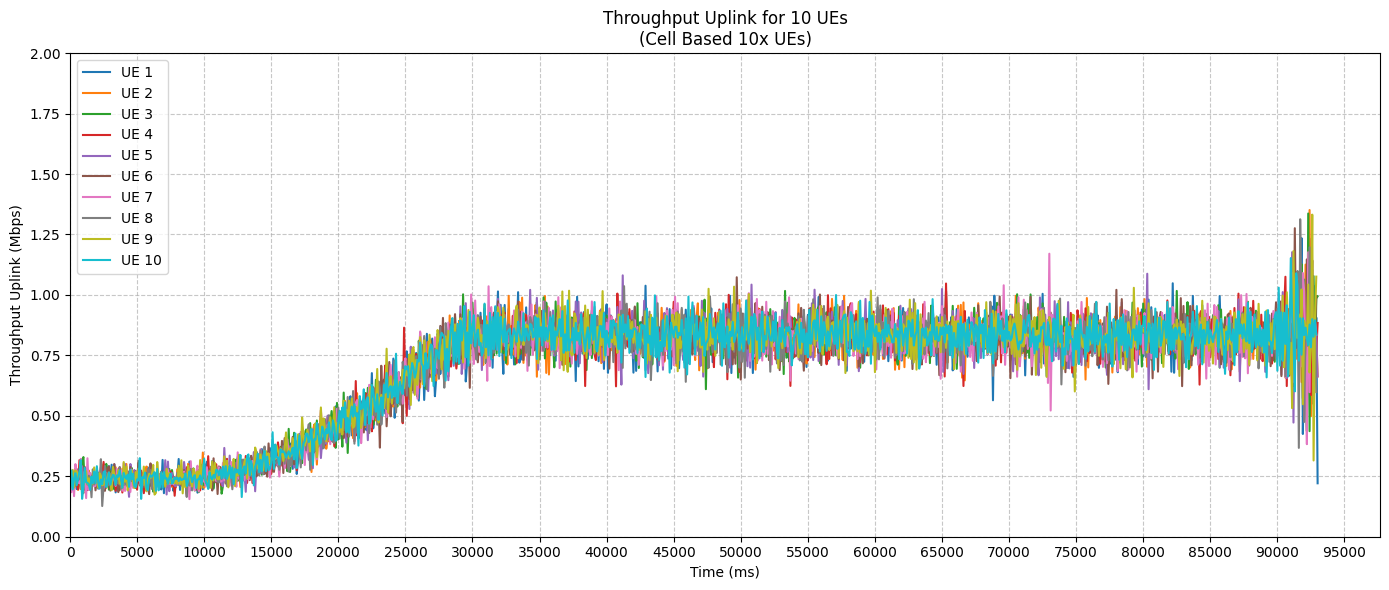

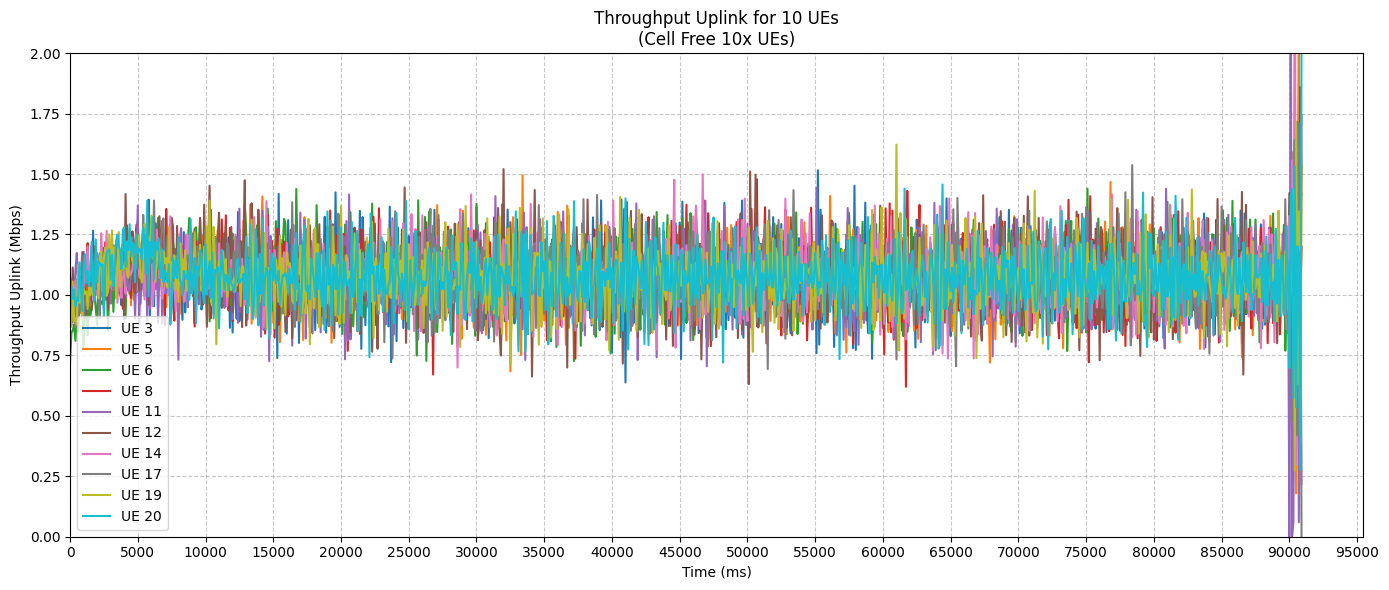

In [ ]:
# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
for ue, df in dfs_cb_10.items():
    sns.lineplot(x="Time_ms", y="Mean_Throughput", data=df, label=f"UE {ue}")
plt.title("Throughput Uplink for 10 UEs\n(Cell Based 10x UEs)")
plt.xlabel("Time (ms)")
plt.ylabel("Throughput Uplink (Mbps)")
plt.grid(True)
plt.legend()

plt.ylim(0, 2)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
for ue, df in dfs_cf_10.items():
    sns.lineplot(x="Time_ms", y="Mean_Throughput", data=df, label=f"UE {ue}")
plt.title("Throughput Uplink for 10 UEs\n(Cell Free 10x UEs)")
plt.xlabel("Time (ms)")
plt.ylabel("Throughput Uplink (Mbps)")
plt.grid(True)
plt.legend()

plt.ylim(0, 2)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df_cb_10 = pd.read_csv(cb_10x)
df_cf_10 = pd.read_csv(cf_10x)

print(df_cb_10["Mean_Throughput"].describe())
print(df_cf_10["Mean_Throughput"].describe())

count    9305.000000
mean        0.694961
std         0.237921
min         0.126890
25%         0.559074
50%         0.794759
75%         0.858258
max         1.351085
Name: Mean_Throughput, dtype: float64
count    9100.000000
mean        1.072843
std         0.136698
min         0.000000
25%         0.987553
50%         1.071210
75%         1.157609
max         2.623100
Name: Mean_Throughput, dtype: float64


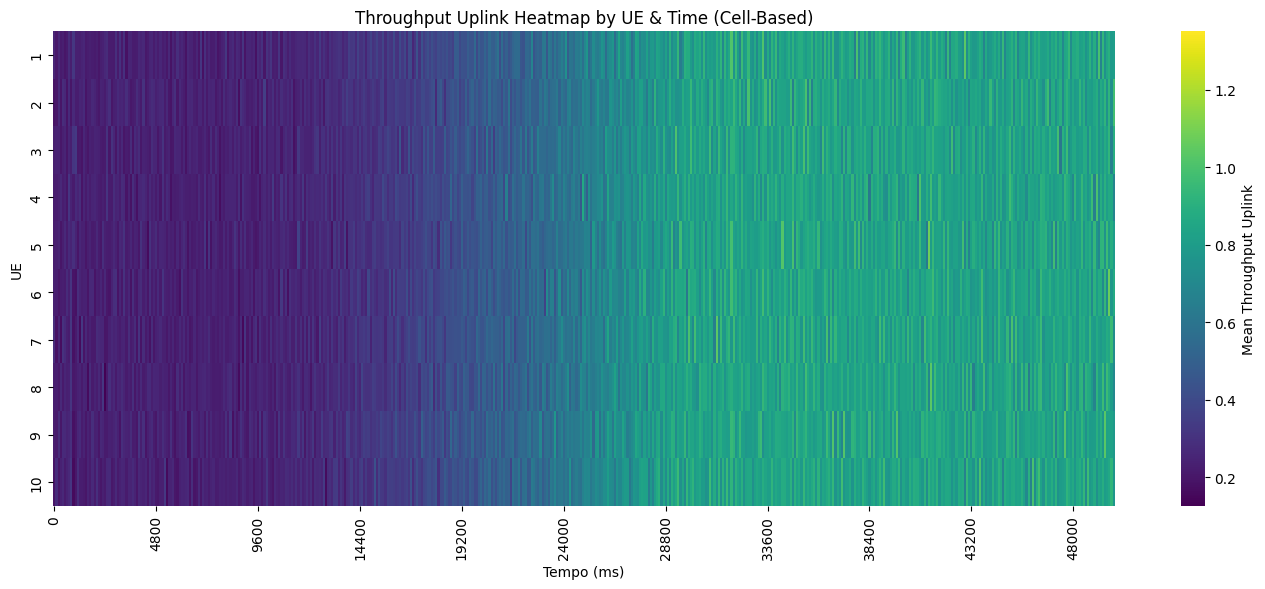

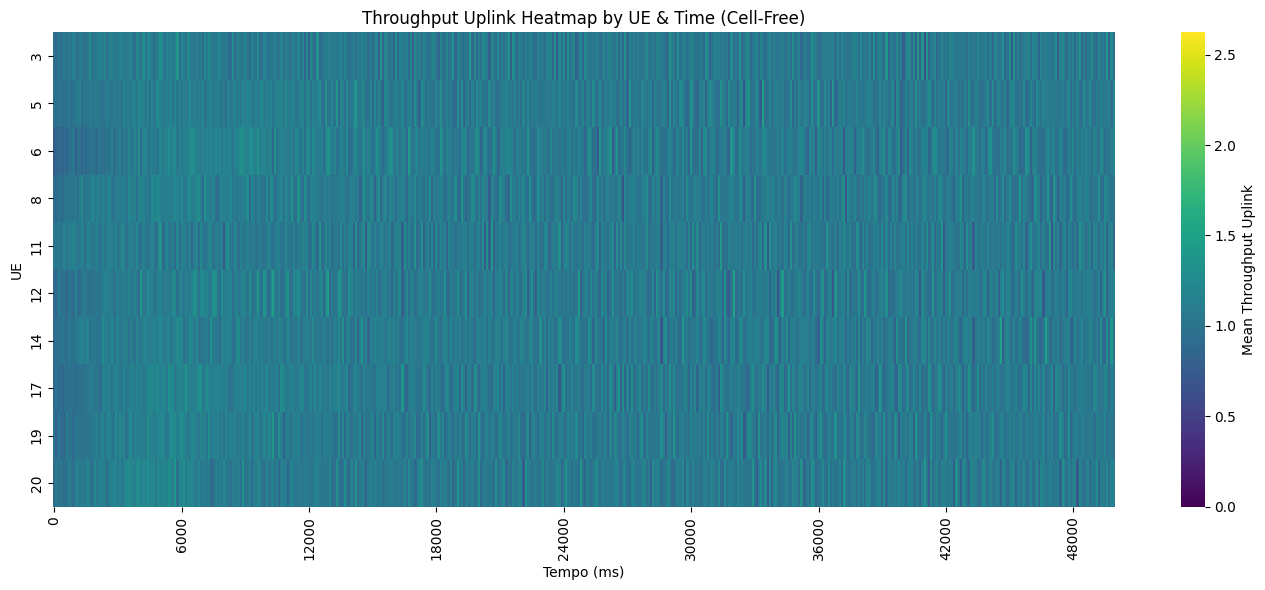

In [ ]:

heat_cb = df_cb_10.pivot(index="UE_ID", columns="Time_ms", values="Mean_Throughput")
heat_cf = df_cf_10.pivot(index="UE_ID", columns="Time_ms", values="Mean_Throughput")

# Plot Cell-Based
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cb, cmap="viridis", cbar_kws={'label': 'Mean Throughput Uplink (Mbps)'})
plt.title("Throughput Uplink Heatmap by UE & Time (Cell-Based)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.tight_layout()
plt.xlim(0,500)
plt.show()

# Plot Cell-Free
plt.figure(figsize=(14, 6))
sns.heatmap(heat_cf, cmap="viridis", cbar_kws={'label': 'Mean Throughput Uplink (Mbps)'})
plt.title("Throughput Uplink Heatmap by UE & Time (Cell-Free)")
plt.xlabel("Tempo (ms)")
plt.locator_params(axis="x", nbins=20)
plt.ylabel("UE")
plt.xlim(0,500)
plt.tight_layout()
plt.show()

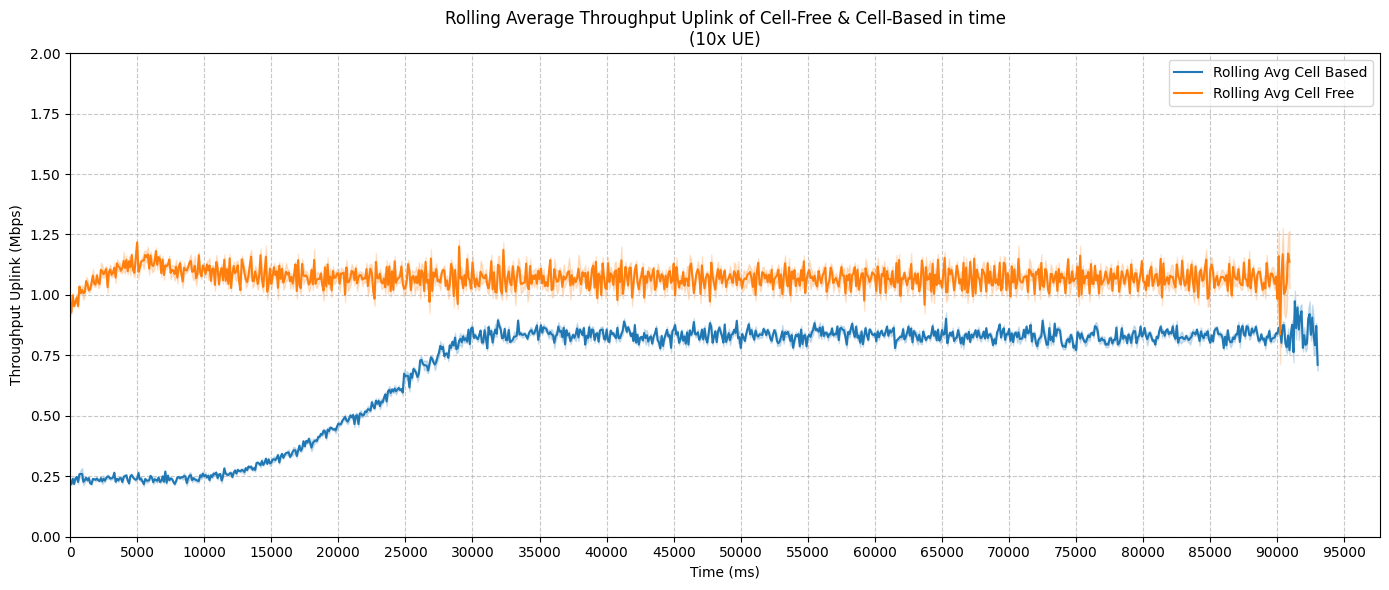

In [ ]:
# Round of throughput values to 3 decimal places
df_cb_10["Mean_Throughput"] = df_cb_10["Mean_Throughput"].round(3)
# Calculate rolling average with a window of 5
df_cb_10["Rolling Avg (Mbps)"] = df_cb_10["Mean_Throughput"].rolling(window=5).mean()

# Round of throughput values to 3 decimal places
df_cf_10["Mean_Throughput"] = df_cf_10["Mean_Throughput"].round(3)
# Calculate rolling average with a window of 5
df_cf_10["Rolling Avg (Mbps)"] = df_cf_10["Mean_Throughput"].rolling(window=5).mean()

# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
sns.lineplot(x="Time_ms", y="Rolling Avg (Mbps)", data=df_cb_10, label="Rolling Avg Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (Mbps)", data=df_cf_10, label="Rolling Avg Cell Free")
plt.title("Rolling Average Throughput Uplink of Cell-Free & Cell-Based in time\n(10x UE)")
plt.xlabel("Time (ms)")
plt.ylabel("Throughput Uplink (Mbps)")
plt.legend()

plt.grid(True)
plt.ylim(0, 2)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# All Datasets

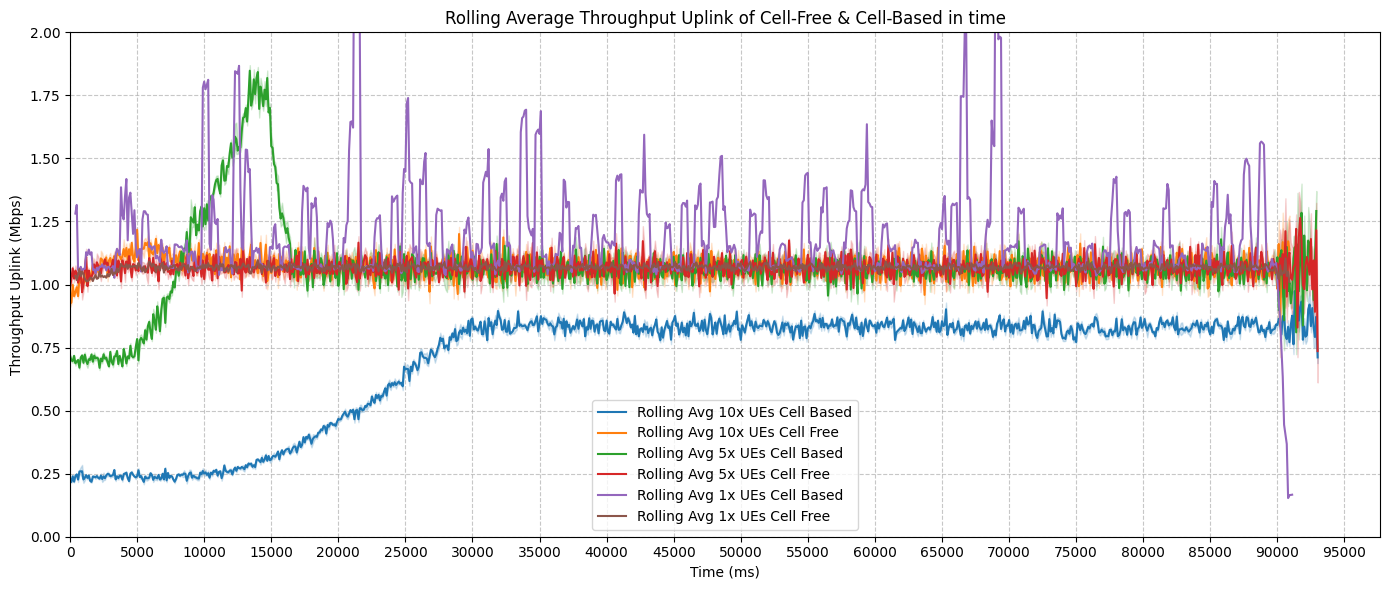

In [18]:
# Round of throughput values to 3 decimal places
df_cb_1["Mean_Throughput"] = df_cb_1["Mean_Throughput"].round(3)
df_cb_1["Rolling Avg (Mbps)"] = df_cb_1["Mean_Throughput"].rolling(window=5).mean()
df_cf_1["Mean_Throughput"] = df_cf_1["Mean_Throughput"].round(3)
df_cf_1["Rolling Avg (Mbps)"] = df_cf_1["Mean_Throughput"].rolling(window=5).mean()

# Round of throughput values to 3 decimal places
df_cb_5["Mean_Throughput"] = df_cb_5["Mean_Throughput"].round(3)
df_cb_5["Rolling Avg (Mbps)"] = df_cb_5["Mean_Throughput"].rolling(window=5).mean()
df_cf_5["Mean_Throughput"] = df_cf_5["Mean_Throughput"].round(3)
df_cf_5["Rolling Avg (Mbps)"] = df_cf_5["Mean_Throughput"].rolling(window=5).mean()

# Round of throughput values to 3 decimal places
df_cb_10["Mean_Throughput"] = df_cb_10["Mean_Throughput"].round(3)
df_cb_10["Rolling Avg (Mbps)"] = df_cb_10["Mean_Throughput"].rolling(window=5).mean()
df_cf_10["Mean_Throughput"] = df_cf_10["Mean_Throughput"].round(3)
df_cf_10["Rolling Avg (Mbps)"] = df_cf_10["Mean_Throughput"].rolling(window=5).mean()

# Graphic of Throughput and Rolling Average
plt.figure(figsize=(14, 6))
sns.lineplot(x="Time_ms", y="Rolling Avg (Mbps)", data=df_cb_10, label="Rolling Avg 10x UEs Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (Mbps)", data=df_cf_10, label="Rolling Avg 10x UEs Cell Free")
sns.lineplot(x="Time_ms", y="Rolling Avg (Mbps)", data=df_cb_5, label="Rolling Avg 5x UEs Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (Mbps)", data=df_cf_5, label="Rolling Avg 5x UEs Cell Free")
sns.lineplot(x="Time_ms", y="Rolling Avg (Mbps)", data=df_cb_1, label="Rolling Avg 1x UEs Cell Based")
sns.lineplot(x="Time_ms", y="Rolling Avg (Mbps)", data=df_cf_1, label="Rolling Avg 1x UEs Cell Free")
plt.title("Rolling Average Throughput Uplink of Cell-Free & Cell-Based in time")
plt.xlabel("Time (ms)")
plt.ylabel("Throughput Uplink (Mbps)")
plt.legend()

plt.grid(True)
plt.ylim(0, 2)
plt.xlim(left=0)
plt.gca().xaxis.set_major_locator(MultipleLocator(5000))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Stats

## Mean Throughput Uplink (Mbps)

| Métrica      | CB (1x UEs) | CF (1x UEs) | CB (5x UEs) | CF (5x UEs) | CB (10x UEs) | CF (10x UEs) |
|--------------|-----------|-----------|-------------|-------------|--------------|--------------|
| Count        | 907       | 910       | 4650        | 4655        | 9305         | 9100         |
| Mean         | 1.191     | 1.067     | 1.070       | 1.068       | 0.695        | 1.073        |
| Std          | 0.445     | 0.053     | 0.234       | 0.128       | 0.238        | 0.137        |
| Min          | 0.000     | 0.839     | 0.391       | 0.000       | 0.127        | 0.000        |
| 25%          | 1.036     | 1.033     | 0.982       | 0.998       | 0.560        | 0.988        |
| 50% (Median) | 1.073     | 1.068     | 1.061       | 1.066       | 0.795        | 1.071        |
| 75%          | 1.129     | 1.102     | 1.139       | 1.137       | 0.858        | 1.158        |
| Max          | 5.880     | 1.308     | 2.586       | 2.154       | 1.351        | 2.623        |


## Requirements

|                | VM RAN    | VM CN     | VM UEs      |  VM FlexRIC | 
|--------------  |-----------|-----------|-------------|-------------|
| CPU            | 12        | 2         | 14          | 4           | 
| RAM (GiB)      | 24        | 2         | 20          | 6           | 
| Storage  (GiB) | 76        | 25        | 50          | 50          | 
